# Recolección y preparación de datos históricos

Obtener datos de temperatura registrados en ThingSpeak (canal Edafica, field1), procesarlos, limpiarlos y dejarlos listos para usarlos como entrada del modelo IA.

## Extraer los datos de ThingSpeak

In [4]:
import requests
import pandas as pd
from dateutil import parser

# Parámetros
API_URL = "https://api.thingspeak.com/channels/2791082/fields/1.json"
API_KEY = "IQUFKGVTQRH7TNBU"
NUM_DATOS = 8000  # puedes ajustar este número según lo que necesites

# Solicitud HTTP
params = {
    "api_key": API_KEY,
    "results": NUM_DATOS
}

response = requests.get(API_URL, params=params)

# Verificar estado
if response.status_code != 200:
    raise Exception(f"Error en la solicitud: {response.status_code}")

datos = response.json()["feeds"]

## Convertir a DataFrame y limpiar

In [7]:
# Convertir a DataFrame
df = pd.DataFrame(datos)

# Seleccionar columnas necesarias
df = df[["created_at", "field1"]].copy()

# Renombrar columnas
df.columns = ["fecha", "temperatura"]

# Convertir fecha a datetime
df["fecha"] = pd.to_datetime(df["fecha"])

# Convertir temperatura a float
df["temperatura"] = pd.to_numeric(df["temperatura"], errors="coerce")

# Eliminar filas con NaN
df = df.dropna().reset_index(drop=True)

## Verificación rápida de los datos

In [10]:
print(df.head())
print(df.dtypes)
print(f"Total de registros limpios: {len(df)}")

                      fecha  temperatura
0 2024-12-20 01:41:21+00:00            1
1 2024-12-20 01:41:38+00:00            1
2 2024-12-20 01:41:57+00:00            1
3 2024-12-20 01:42:14+00:00            1
4 2024-12-20 01:47:52+00:00            1
fecha          datetime64[ns, UTC]
temperatura                  int64
dtype: object
Total de registros limpios: 75


## Gráfica

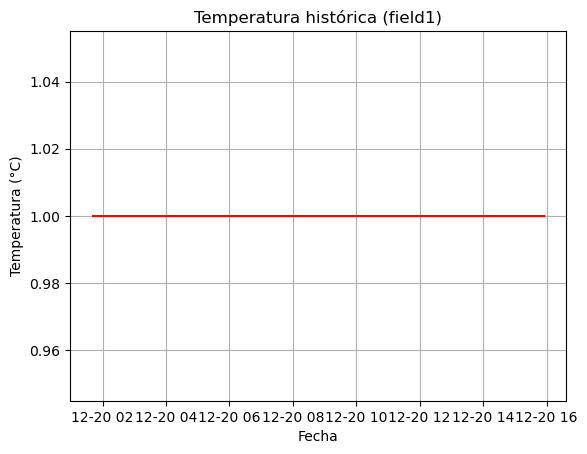

In [13]:
import matplotlib.pyplot as plt

plt.plot(df["fecha"], df["temperatura"], color="red")
plt.title("Temperatura histórica (field1)")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()